# 4. Agglomerative Clustering实验

## 4.1 Agglomerative 聚类简介（主要思想与参数）

### 什么是 Agglomerative Clustering？

Agglomerative Clustering 是一种层次聚类（Hierarchical Clustering）算法。

它属于：自底向上（Bottom-Up）的聚类方法。

算法开始时：

每个样本点都视为一个独立聚类，然后不断合并距离最近的两个聚类，最终形成一个完整的层次结构树（Dendrogram）。

Agglomerative Clustering 特别适用于：

- 层次结构明显的数据
- 小规模数据集
- 需要观察聚类合并过程的任务

### Agglomerative 的核心思想

#### Agglomerative Clustering 的基本思想：

从最小聚类开始，不断合并最相近的聚类。
#### 聚类过程：
每个点单独成类

↓

寻找最近的两个类

↓

进行合并

↓

重复上述步骤

↓

直到达到指定聚类数量

### Agglomerative 的重要参数
1）n_clusters

表示最终聚类数量。

例如：

n_clusters=3

表示最终划分为 3 个聚类。

（2）linkage

表示：聚类之间距离的计算方式

常见 linkage：


ward ---	最小化类内方差

single --- 最近点距离

complete --- 最远点距离

average	--- 平均距离

#### 不同 linkage 的特点
ward：
- 最常用
- 聚类效果通常较好
- 适合球状数据
  
single：
- 容易形成“链式结构”
- 对噪声敏感
  
complete：
- 聚类更紧密
- 对离群点较稳定
  
average:
- 综合效果较平衡
- 使用平均距离

Agglomerative 的优点:
能生成层次结构; 不需要随机初始化; 聚类结果稳定

Agglomerative 的缺点:
计算量较大; 大数据集较慢; 对噪声敏感

### 🌱 课前准备




### 📦 所需环境


In [2]:
pip install numpy pandas matplotlib scikit-learn seaborn scipy

Note: you may need to restart the kernel to use updated packages.


## 4.2 Agglomerative 聚类与可视化
### 实验目的

本实验中：

- 使用 Iris 数据集
- 使用 t-SNE 进行二维降维
- 使用 Agglomerative Clustering 聚类
- 绘制聚类散点图
- 绘制层次聚类树状图（Dendrogram）

实验流程  
1.导入 Iris 数据集    
2.数据标准化  
3.t-SNE 降维  
4.Agglomerative 聚类  
5.聚类结果可视化  
6.绘制树状图  

In [3]:
# 导入库
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage

#### 加载数据集与数据预处理

In [4]:
# =====================================
# Step 1: 导入数据集
# =====================================

iris = load_iris()
X = iris.data

# =====================================
# Step 2: 数据标准化
# =====================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### t-SNE降维
原因：这里使用 t-SNE 降维，主要是因为 Iris 数据集原本具有 4 个特征，而人眼无法直接观察四维空间中的数据分布。因此，需要通过降维方法将高维数据压缩到二维空间，方便后续聚类结果的可视化展示。在本实验中之所以选择 t-SNE，而不是普通的 PCA，是因为 t-SNE 更擅长保留数据之间的局部结构关系。简单来说，如果两个样本在原始高维空间中彼此接近，那么经过 t-SNE 降维后，它们在二维图中通常仍然会靠得很近。因此，t-SNE 特别适合用于聚类结果的可视化，可以让不同类别之间的边界更加清晰，更容易观察 Agglomerative Clustering 的聚类效果。

PCA 更擅长保留数据的整体结构，
因此适用于 DBSCAN 中的密度分布观察；

而 t-SNE 更擅长保留局部邻域关系，
能够更清晰地展示 Agglomerative Clustering 的聚类边界，
因此本实验采用 t-SNE 进行二维可视化。

In [6]:
# =====================================
# Step 3: t-SNE降维
# =====================================

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_scaled)


#### 聚类并统计数量

In [7]:
# =====================================
# Step 4: Agglomerative聚类
# =====================================

agg = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

labels = agg.fit_predict(X_scaled)
# ====================================
# Cluster analysis
# ====================================

# 聚类数量
n_clusters = len(set(labels))

print("Total clusters:", n_clusters)

# 每个聚类中的样本数量
for cluster_id in set(labels):

    n_samples = list(labels).count(cluster_id)

    print(f"Cluster {cluster_id}: {n_samples} samples")

Total clusters: 3
Cluster 0: 71 samples
Cluster 1: 49 samples
Cluster 2: 30 samples


#### 结果可视化

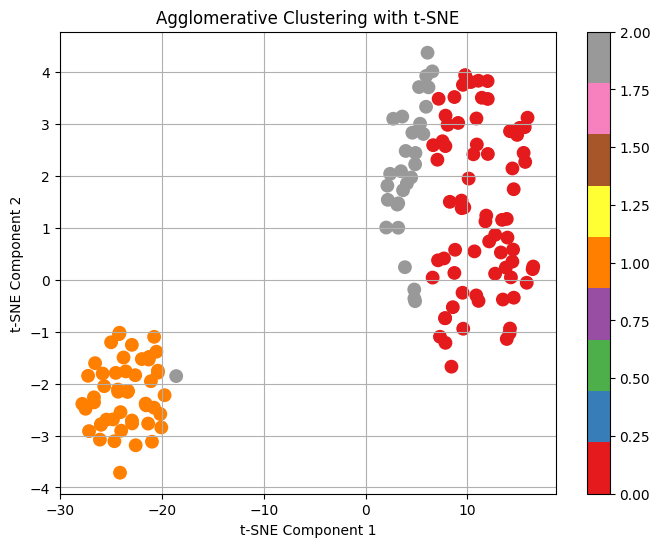

In [8]:
# =====================================
# Step 5: 聚类结果可视化
# =====================================

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=labels,
    cmap='Set1',
    s=80
)

plt.title("Agglomerative Clustering with t-SNE")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.colorbar(scatter)

plt.grid(True)
plt.show()

#### 聚类树状图

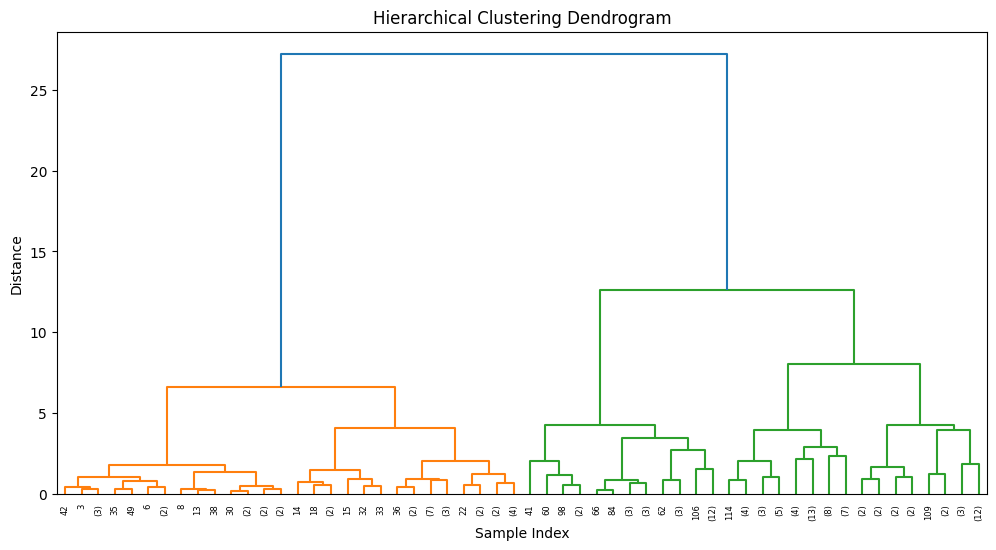

In [9]:
# =====================================
# 绘制层次聚类树状图
# =====================================

linked = linkage(
    X_scaled,
    method='ward'
)

plt.figure(figsize=(12,6))

dendrogram(
    linked,
    truncate_mode='level',
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")

plt.show()

#### 实验结果分析
t-SNE 可视化  
t-SNE 将高维数据映射到二维空间。

其特点：  
- 保留局部结构
- 聚类边界更清晰
- 可视化效果优于 PCA

Agglomerative 聚类结果：    
Agglomerative 会不断合并距离最近的聚类。

图中：  
不同颜色表示不同聚类，聚类边界较明显

#### 树状图分析

树状图（Dendrogram）展示了聚类是如何一步步合并的

纵轴表示聚类距离  

距离越大说明两个聚类差异越大。

## 4.3 不同参数下的 Agglomerative 实验
### 实验目的

本部分研究：不同 linkage 方法对聚类效果的影响。

并使用DBI（Davies-Bouldin Index）评价聚类质量。

同时与：K-Means进行比较。

### 什么是 DBI？

DBI（Davies-Bouldin Index）用于评价聚类质量。

DBI 的含义
DBI 越小：

- 类内距离更小
- 类间距离更大
- 聚类效果更好
  
DBI 越大：
- 说明聚类效果较差。

### Agglomerative 参数实验

In [10]:
# 导入库
import pandas as pd

from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score

#### 参数实验与对比实验

In [11]:
# ====================================
# Agglomerative 参数实验 + K-Means 对比
# ====================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import davies_bouldin_score

# Linkage 方法列表
linkage_methods = [
    'ward',
    'single',
    'complete',
    'average'
]

results = []

# ====================================
# 测试不同 linkage 方法
# ====================================

for method in linkage_methods:

    agg = AgglomerativeClustering(
        n_clusters=3,
        linkage=method
    )

    labels = agg.fit_predict(X_scaled)

    dbi = davies_bouldin_score(
        X_scaled,
        labels
    )

    results.append([
        method,
        dbi
    ])

# ====================================
# 输出 Agglomerative 参数实验结果
# ====================================

results_df = pd.DataFrame(
    results,
    columns=[
        'Linkage',
        'DBI'
    ]
)

print("Agglomerative Parameter Test Results:")
print(results_df)

# ====================================
# 找到最优 Agglomerative 结果
# ====================================

best_agg = results_df.loc[
    results_df['DBI'].idxmin()
]

print("\nBest Agglomerative Result:")
print(best_agg)

# ====================================
# K-Means 对比实验
# ====================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_dbi = davies_bouldin_score(
    X_scaled,
    kmeans_labels
)

print("\nK-Means Result:")
print("K-Means DBI:", kmeans_dbi)

# ====================================
# Agglomerative 与 K-Means 对比表
# ====================================

comparison_df = pd.DataFrame({
    'Method': [
        'Best Agglomerative',
        'K-Means'
    ],
    'DBI': [
        best_agg['DBI'],
        kmeans_dbi
    ]
})

print("\nComparison between Agglomerative and K-Means:")
print(comparison_df)

Agglomerative Parameter Test Results:
    Linkage       DBI
0      ward  0.803467
1    single  0.492925
2  complete  0.758358
3   average  0.575269

Best Agglomerative Result:
Linkage      single
DBI        0.492925
Name: 1, dtype: object

K-Means Result:
K-Means DBI: 0.7893630242997912

Comparison between Agglomerative and K-Means:
               Method       DBI
0  Best Agglomerative  0.492925
1             K-Means  0.789363


- 实验结果可视化

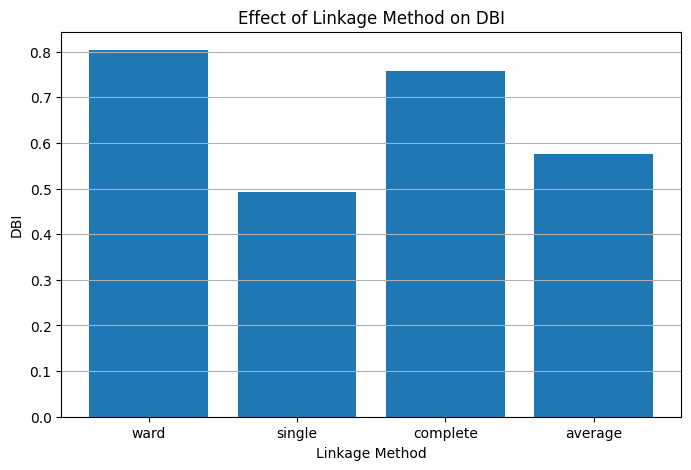

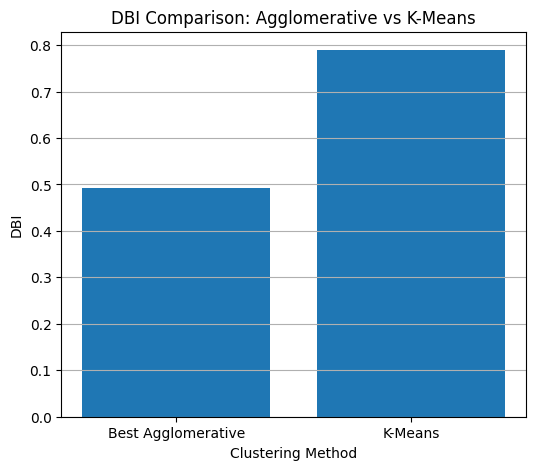

In [12]:
# ====================================
# linkage 方法对 DBI 的影响
# ====================================

plt.figure(figsize=(8,5))

plt.bar(
    results_df['Linkage'],
    results_df['DBI']
)

plt.title("Effect of Linkage Method on DBI")
plt.xlabel("Linkage Method")
plt.ylabel("DBI")

plt.grid(axis='y')
plt.show()
# ====================================
# Agglomerative 与 K-Means 的 DBI 对比图
# ====================================

plt.figure(figsize=(6,5))

plt.bar(
    comparison_df['Method'],
    comparison_df['DBI']
)

plt.title("DBI Comparison: Agglomerative vs K-Means")
plt.xlabel("Clustering Method")
plt.ylabel("DBI")

plt.grid(axis='y')
plt.show()

实验结果表明，不同 linkage 方法会影响 Agglomerative Clustering 的聚类效果。DBI 值越小，说明聚类结果越好。通过与 K-Means 的 DBI 结果进行比较，可以判断在 Iris 数据集上哪种聚类方法具有更好的聚类质量。

### 实验分析
linkage 对聚类的影响    
ward：
- 聚类效果通常最好
- 类内最紧凑
  
single：
- 易产生链状结构
- 对噪声敏感
  
complete：
- 聚类更加紧密
- 更稳定
  
average：
- 聚类效果较平衡

#### 与 K-Means 的比较
Agglomerative

优点：

- 能构建层次结构
- 聚类稳定
- 不依赖随机初始化

缺点：

- 计算复杂度高
- 大数据速度慢
  
K-Means

优点：

- 速度快
- 实现简单

缺点：

- 需要提前指定聚类数
- 不适合复杂形状数据

### 实验总结


本实验完成了：  

1.Agglomerative 聚类实现  
2.t-SNE 可视化  
3.层次聚类树状图绘制  
4.linkage 参数实验  
5.DBI 聚类评价  
6.与 K-Means 对比  

实验表明：  

Agglomerative Clustering 能较好地展示数据的层次结构，其中：ward linkage通常具有最佳聚类效果。